## Инициализация среды и загрузка исходного среза 

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path("C:/Users/cendv/Desktop/nyc_taxi/data/interim/sample_200k.csv")
df = pl.read_csv(DATA_PATH)
print(f"Загружено записей: {df.shape[0]:,}, колонок: {df.shape[1]}")

Загружено записей: 200,000, колонок: 19


## 1. Приведение типов и расчет длительности
Преобразуем текстовые даты в формат Datetime и рассчитываем длительность поездки в минутах.

In [2]:
df_clean = df.with_columns(
    [
        pl.col("tpep_pickup_datetime").str.to_datetime(),
        pl.col("tpep_dropoff_datetime").str.to_datetime(),
    ]
).with_columns(
    (
        (
            pl.col("tpep_dropoff_datetime") - pl.col("tpep_pickup_datetime")
        ).dt.total_seconds()
        / 60
    ).alias("duration_minutes")
)

## 2. Фильтрация аномалий (на основе docs/DATASET.md)
Удаляем некорректную длительность, нулевые GPS-координаты, отрицательные суммы и нулевое число пассажиров.

In [3]:
df_filtered = df_clean.filter(
    (pl.col("duration_minutes") > 0)
    & (pl.col("duration_minutes") <= 1440)
    & (pl.col("pickup_longitude") != 0)
    & (pl.col("pickup_latitude") != 0)
    & (pl.col("dropoff_longitude") != 0)
    & (pl.col("dropoff_latitude") != 0)
    & (pl.col("fare_amount") > 0)
    & (pl.col("total_amount") > 0)
    & (pl.col("passenger_count") > 0)
)

print(f"Осталось строк после фильтрации: {df_filtered.shape[0]:,}")

Осталось строк после фильтрации: 195,707


## 3. Распределение стоимости поездки (fare_amount)
Визуализируем гистограмму распределения стоимости поездки по тарифу для очищенных данных.

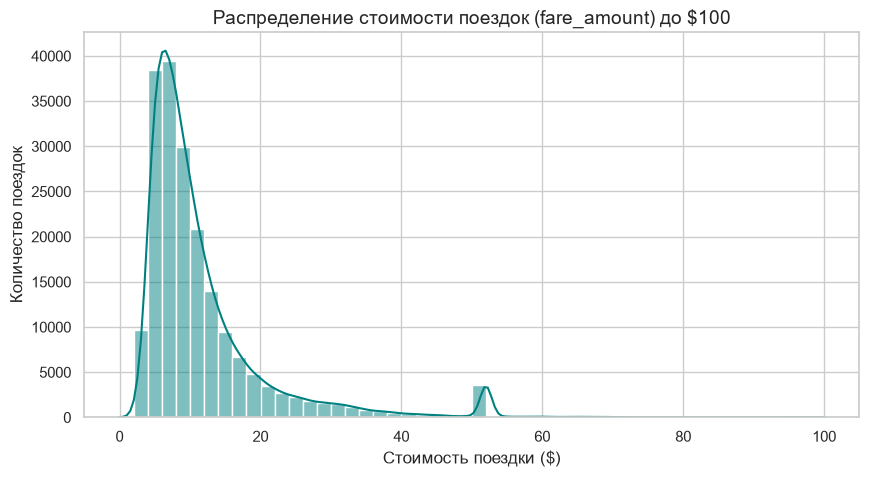

In [4]:
fare_data = df_filtered.filter(pl.col("fare_amount") <= 100)[
    "fare_amount"
].to_numpy()

plt.figure(figsize=(10, 5))
sns.histplot(fare_data, bins=50, kde=True, color="teal")
plt.title("Распределение стоимости поездок (fare_amount) до $100", fontsize=14)
plt.xlabel("Стоимость поездки ($)", fontsize=12)
plt.ylabel("Количество поездок", fontsize=12)
plt.show()

## 4. Сохранение результата

In [5]:
df_filtered.write_csv("sample_200k_cleaned.csv")
print("Файл sample_200k_cleaned.csv сохранен")

Файл sample_200k_cleaned.csv сохранен
